In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

In [3]:
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Reviews:", reviews.shape)
print("Payments:", payments.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)
Products: (32951, 9)
Sellers: (3095, 4)
Reviews: (99224, 7)
Payments: (103886, 5)


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [7]:
orders.duplicated().sum()

np.int64(0)

In [8]:
order_items.duplicated().sum()

np.int64(0)

In [9]:
customers.duplicated().sum()

np.int64(0)

In [10]:
products.duplicated().sum()

np.int64(0)

In [11]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [12]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [13]:
missing_orders = orders.isnull().sum().sort_values(ascending=False)

missing_orders[missing_orders > 0]

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

In [14]:
missing_percentage = (
    orders.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
dtype: float64

In [15]:
orders[
    [
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
].isnull().sum()

order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [16]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors='coerce'
    )

In [17]:
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [18]:
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

In [19]:
orders['delivery_time_days'].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_time_days, dtype: float64

In [20]:
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

In [21]:
orders['on_time_delivery'] = np.where(
    orders['delivery_delay_days'] <= 0,
    1,
    0
)

In [22]:
orders['on_time_delivery'].value_counts()

on_time_delivery
1    88649
0    10792
Name: count, dtype: int64

In [23]:
orders[
    orders['delivery_time_days'] < 0
][
    [
        'order_id',
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'delivery_time_days'
    ]
]

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days


In [24]:
orders.loc[
    orders['delivery_time_days'] < 0,
    'delivery_time_days'
] = np.nan

In [25]:
orders['delivery_time_days'].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_time_days, dtype: float64

In [26]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [27]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [28]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [29]:
order_items['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [30]:
order_items['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [31]:
(order_items['price'] < 0).sum()

np.int64(0)

In [32]:
(order_items['freight_value'] < 0).sum()

np.int64(0)

In [33]:
order_items['total_item_cost'] = (
    order_items['price'] +
    order_items['freight_value']
)

In [34]:
order_items[['price', 'freight_value', 'total_item_cost']].head()

,price,freight_value,total_item_cost
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [35]:
merged_data = orders.merge(
    order_items,
    on='order_id',
    how='left'
)

In [36]:
merged_data.shape

(113425, 18)

In [37]:
merged_data = merged_data.merge(
    customers,
    on='customer_id',
    how='left'
)

In [38]:
merged_data = merged_data.merge(
    sellers,
    on='seller_id',
    how='left'
)

In [39]:
merged_data = merged_data.merge(
    products,
    on='product_id',
    how='left'
)

In [40]:
merged_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay_days,on_time_delivery,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_item_cost,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,1,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,1,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,1,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,1,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,31842.0,belo horizonte,MG,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,1,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,8752.0,mogi das cruzes,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [41]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  str           
 1   customer_id                    113425 non-null  str           
 2   order_status                   113425 non-null  str           
 3   order_purchase_timestamp       113425 non-null  datetime64[us]
 4   order_approved_at              113264 non-null  datetime64[us]
 5   order_delivered_carrier_date   111457 non-null  datetime64[us]
 6   order_delivered_customer_date  110196 non-null  datetime64[us]
 7   order_estimated_delivery_date  113425 non-null  datetime64[us]
 8   delivery_time_days             110196 non-null  float64       
 9   delivery_delay_days            110196 non-null  float64       
 10  on_time_delivery               113425 non-null  int64         
 11  order_item_

In [42]:
merged_data.shape

(113425, 33)

In [44]:
merged_data.isnull().sum().sort_values(
    ascending=False
).head(20)

delivery_time_days               3229
delivery_delay_days              3229
order_delivered_customer_date    3229
product_category_name            2378
product_photos_qty               2378
product_description_lenght       2378
product_name_lenght              2378
order_delivered_carrier_date     1968
product_weight_g                  793
product_height_cm                 793
product_length_cm                 793
product_width_cm                  793
seller_zip_code_prefix            775
seller_id                         775
product_id                        775
order_item_id                     775
price                             775
shipping_limit_date               775
seller_city                       775
seller_state                      775
dtype: int64

In [45]:
final_columns = [
    'order_id',
    'customer_id',
    'order_status',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'delivery_time_days',
    'delivery_delay_days',
    'on_time_delivery',
    'product_id',
    'seller_id',
    'price',
    'freight_value',
    'total_item_cost',
    'customer_city',
    'customer_state',
    'seller_city',
    'seller_state',
    'product_category_name',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

In [46]:
final_data = merged_data[
    [col for col in final_columns if col in merged_data.columns]
].copy()

In [47]:
final_data[
    [
        'product_weight_g',
        'product_length_cm',
        'product_height_cm',
        'product_width_cm'
    ]
].isnull().sum()

product_weight_g     793
product_length_cm    793
product_height_cm    793
product_width_cm     793
dtype: int64

In [48]:
numeric_product_columns = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for column in numeric_product_columns:
    final_data[column] = final_data[column].fillna(
        final_data[column].median()
    )

In [49]:
final_data['product_category_name'] = (
    final_data['product_category_name']
    .fillna('unknown')
)

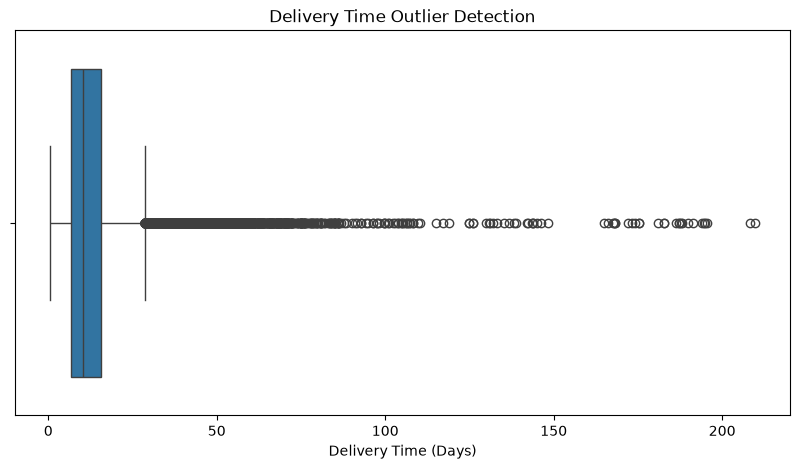

In [50]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=final_data['delivery_time_days'].dropna()
)

plt.title('Delivery Time Outlier Detection')
plt.xlabel('Delivery Time (Days)')
plt.show()

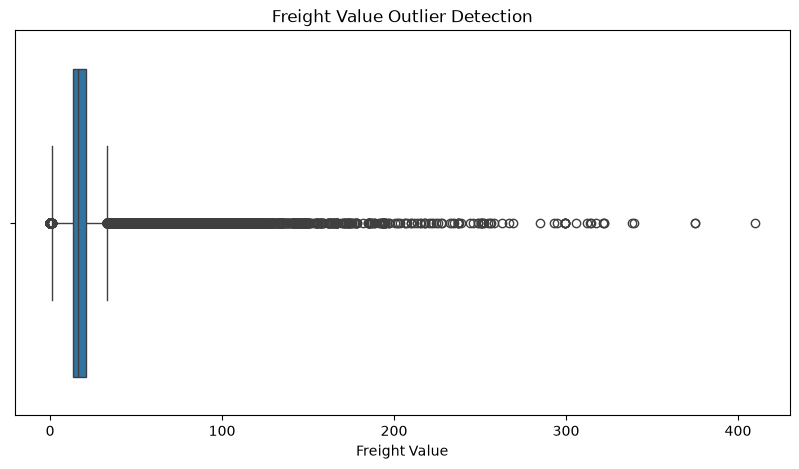

In [51]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=final_data['freight_value'].dropna()
)

plt.title('Freight Value Outlier Detection')
plt.xlabel('Freight Value')
plt.show()

In [52]:
from sklearn.preprocessing import MinMaxScaler

In [53]:
scaler = MinMaxScaler()

final_data[
    ['price', 'freight_value']
] = scaler.fit_transform(
    final_data[['price', 'freight_value']]
)

In [54]:
scaler = MinMaxScaler()

final_data[
    ['price_normalized', 'freight_normalized']
] = scaler.fit_transform(
    final_data[['price', 'freight_value']]
)

In [56]:
final_data.to_csv(
    "../data/processed/olist_logistics_cleaned.csv",
    index=False
)